# Gradient Comparison: `perturbedOptFunc` vs Reference `perturbations.py`

**Date**: 2026-02-26

## The Two Formulations

### Reference (`perturbations.py`) — *Perturbed Solution Map*

Forward: $\bar{z}(\theta) = \mathbb{E}_\varepsilon[z(\theta + \sigma\varepsilon)]$ (expected **solution vector**)

Backward: Jacobian–vector product via log-derivative trick:
$$g_d = \frac{1}{N\sigma} \sum_n \left( z_n \cdot \text{dy} \right) \nabla\!\log p(\varepsilon_n)_d$$

where $z_n = z(\theta + \sigma\varepsilon_n)$ is a **vector** (the solution), and dy is the upstream gradient from the loss function w.r.t. the solution.

This is a *differentiable solver* — it returns a soft solution, and gradients from any downstream loss propagate through via the chain rule.

### Ours (`perturbedOptFunc`) — *Perturbed Objective*

Forward: $\bar{f}(\theta) = \mathbb{E}_\varepsilon[f(\theta^*, z(\theta + \sigma\varepsilon))]$ (expected **scalar objective**)

Backward: REINFORCE with scalar scores:
$$g_d = \frac{\text{dy}}{N\sigma} \sum_n f_n \, \nabla\!\log p(\varepsilon_n)_d$$

where $f_n = f(\theta^*, z_n)$ is a **scalar** (the objective value under true coefficients).

### Are they equivalent?

**Only when $f$ is linear in $z$**: if $f = c^T z$, then $f_n \cdot \nabla\!\log p = (c^T z_n) \cdot \nabla\!\log p$ and the chain rule through the reference gives $c^T \cdot \frac{\partial \bar{z}}{\partial \theta}$ which is the same thing (since dy = c).

**But for nonlinear objectives** (e.g., portfolio's quadratic $p^T z - \alpha \|Lz\|^2$), they diverge.

This notebook compares them numerically on controlled problems.

In [1]:
import sys, os, importlib
import torch
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# The reference dir has dashes in name — import via sys.path manipulation
REF_DIR = os.path.join(PROJECT_ROOT, 'perturbations-differential-pytorch')
sys.path.insert(0, REF_DIR)
import perturbations as ref_perturbations  # reference impl

torch.manual_seed(42)
print(f"torch {torch.__version__}, device: {torch.device('cpu')}")

torch 2.6.0+cu124, device: cpu


## Helper: Reproduce Our Backward Pass

Extract the REINFORCE gradient from `perturbedOptFunc` into a standalone function so we can compare apple-to-apple with the reference.

In [2]:
from perturbations import sample_noise_with_gradients, SUPPORTED_NOISES


def ours_forward_backward(theta, solver_fn, obj_fn, n_samples, sigma,
                          noise='normal'):
    """
    Reproduce perturbedOptFunc's forward + backward on CPU.
    
    Args:
        theta:      (B, D) predicted cost vector (requires_grad)
        solver_fn:  theta -> z, returns (B, D_sol) solution
        obj_fn:     (z,) -> (B,) scalar objective under true coefficients
        n_samples:  N
        sigma:      perturbation scale
    
    Returns:
        e_obj:  (B,) expected objective
        grad:   (B, D) gradient of e_obj w.r.t. theta
    """
    B, D = theta.shape
    perturbed_shape = [n_samples, B, D]
    
    noise_samples, noise_grad = sample_noise_with_gradients(noise, perturbed_shape)
    # noise_samples, noise_grad: (N, B, D)
    
    perturbed_input = theta.unsqueeze(0) + sigma * noise_samples  # (N, B, D)
    
    # Forward: solve each sample, evaluate scalar objective
    per_sample_objs = []
    for n in range(n_samples):
        z_n = solver_fn(perturbed_input[n].detach())  # (B, D_sol)
        f_n = obj_fn(z_n)                              # (B,)
        per_sample_objs.append(f_n.detach())
    per_sample_objs = torch.stack(per_sample_objs, dim=0)  # (N, B)
    
    e_obj = per_sample_objs.mean(dim=0)  # (B,)
    
    # Backward (our REINFORCE): g_d = (1/Nσ) Σ_n f_n * ∇log p(ε_n)_d
    # Then multiply by dy=1 (since we want ∂e_obj/∂θ directly)
    output = per_sample_objs.unsqueeze(-1)    # (N, B, 1)
    dy = torch.ones(B, 1)                     # upstream = 1 for direct grad
    
    g = torch.einsum(
        'nbd,nb->bd',
        noise_grad,  # (N, B, D)
        torch.einsum('nbd,bd->nb', output, dy),  # (N, B)
    )
    g /= sigma * n_samples
    
    return e_obj, g, noise_samples, per_sample_objs


def ref_forward_backward(theta, solver_fn, obj_fn, n_samples, sigma,
                         noise='normal'):
    """
    Reference perturbations.py approach: differentiate the SOLUTION MAP,
    then chain-rule through the objective.
    
    Returns:
        e_obj:  (B,) expected objective (for comparison)
        grad:   (B, D) gradient of obj(E[z]) w.r.t. theta  [*see note below]
    
    Note: The reference differentiates E[z(θ+σε)], giving a Jacobian.
    We compose with obj_fn to get the full gradient via autograd.
    """
    theta_ref = theta.detach().clone().requires_grad_(True)
    
    # Use the reference perturbed decorator to create a differentiable solver
    soft_solver = ref_perturbations.perturbed(
        solver_fn, num_samples=n_samples, sigma=sigma, noise=noise,
        batched=True, device=torch.device('cpu')
    )
    
    # Forward: get soft (expected) solution
    z_soft = soft_solver(theta_ref)  # (B, D_sol)  — differentiable
    
    # Evaluate objective on the soft solution
    obj_val = obj_fn(z_soft)  # (B,)
    
    # Backward: chain rule through obj -> soft solver -> theta
    loss = obj_val.sum()
    loss.backward()
    
    return obj_val.detach(), theta_ref.grad.detach()


print("Helper functions defined.")

Helper functions defined.


## Test 1: Linear Objective (Should Match)

Solver: argmax (top-k selection)  
Objective: $f = c^T z$ (linear in z)  

For a linear objective, both formulations should give the same gradient because:
$$\nabla_\theta \mathbb{E}[c^T z(\theta+\sigma\varepsilon)] = c^T \nabla_\theta \mathbb{E}[z(\theta+\sigma\varepsilon)]$$

In [3]:
# Linear objective test
D = 5
B = 3
K = 2  # top-K
N = 10000  # many samples for low variance
sigma = 0.5

torch.manual_seed(42)
theta = torch.randn(B, D)
c_true = torch.randn(B, D)  # true coefficients

def topk_solver(costs):
    """Select top-K elements (1-hot encoding)."""
    _, idx = costs.topk(K, dim=-1)
    z = torch.zeros_like(costs)
    z.scatter_(-1, idx, 1.0)
    return z

def linear_obj(z):
    """f = c_true^T z  (linear in z)."""
    return (c_true * z).sum(dim=-1)

# Our gradient
torch.manual_seed(0)
e_obj_ours, grad_ours, _, _ = ours_forward_backward(
    theta, topk_solver, linear_obj, N, sigma
)

# Reference gradient
torch.manual_seed(0)
e_obj_ref, grad_ref = ref_forward_backward(
    theta, topk_solver, linear_obj, N, sigma
)

print("=== Test 1: Linear Objective (should match) ===")
print(f"E[obj] ours:  {e_obj_ours.numpy()}")
print(f"E[obj] ref:   {e_obj_ref.numpy()}")
print(f"\nGrad ours:\n{grad_ours.numpy()}")
print(f"\nGrad ref:\n{grad_ref.numpy()}")
print(f"\nMax |diff|:   {(grad_ours - grad_ref).abs().max().item():.6f}")
print(f"Cosine sim:   {torch.nn.functional.cosine_similarity(grad_ours.flatten().unsqueeze(0), grad_ref.flatten().unsqueeze(0)).item():.6f}")

=== Test 1: Linear Objective (should match) ===
E[obj] ours:  [1.1332883  1.3395311  0.18645823]
E[obj] ref:   [1.1332881 1.339531  0.1864582]

Grad ours:
[[ 3.1973466e-01  6.2187821e-01  1.9894886e-01 -1.2075776e+00
  -6.2264349e-02]
 [ 2.2956817e-01  3.4396611e-02 -5.6470733e-02  1.4578569e-01
  -3.0007067e-01]
 [-1.2851463e-01  2.8013653e-01 -1.5090466e-01 -7.2944388e-03
  -1.1098405e-03]]

Grad ref:
[[ 3.1973466e-01  6.2187821e-01  1.9894886e-01 -1.2075776e+00
  -6.2264349e-02]
 [ 2.2956817e-01  3.4396611e-02 -5.6470733e-02  1.4578569e-01
  -3.0007067e-01]
 [-1.2851463e-01  2.8013653e-01 -1.5090466e-01 -7.2944388e-03
  -1.1098405e-03]]

Max |diff|:   0.000000
Cosine sim:   1.000000


## Test 2: Quadratic Objective (Should Diverge)

Solver: argmax (top-k selection)  
Objective: $f = c^T z - \alpha \|z\|^2$ (quadratic, like portfolio)

For nonlinear objectives, the two formulations give **different** gradients:
- **Reference**: $\nabla_\theta \text{obj}(\mathbb{E}[z])$ — gradient of objective evaluated at the **expected** solution
- **Ours**: $\nabla_\theta \mathbb{E}[\text{obj}(z)]$ — gradient of the **expected** objective

By Jensen's inequality, these differ when obj is nonlinear.

In [4]:
# Quadratic objective test
alpha = 1.0

def quad_obj(z):
    """f = c_true^T z - alpha * ||z||^2  (quadratic in z, like portfolio)."""
    return (c_true * z).sum(dim=-1) - alpha * (z ** 2).sum(dim=-1)

# Our gradient
torch.manual_seed(0)
e_obj_ours, grad_ours, _, _ = ours_forward_backward(
    theta, topk_solver, quad_obj, N, sigma
)

# Reference gradient: chain rule through obj(E[z])
torch.manual_seed(0)
e_obj_ref, grad_ref = ref_forward_backward(
    theta, topk_solver, quad_obj, N, sigma
)

print("=== Test 2: Quadratic Objective (should diverge) ===")
print(f"E[obj] ours:  {e_obj_ours.numpy()}  (E[f(z_n)])")
print(f"obj(E[z]) ref: {e_obj_ref.numpy()}  (f(E[z_n]))")
print(f"\nGrad ours:\n{grad_ours.numpy()}")
print(f"\nGrad ref:\n{grad_ref.numpy()}")
print(f"\nMax |diff|:   {(grad_ours - grad_ref).abs().max().item():.6f}")
cos = torch.nn.functional.cosine_similarity(
    grad_ours.flatten().unsqueeze(0),
    grad_ref.flatten().unsqueeze(0)
).item()
print(f"Cosine sim:   {cos:.6f}")
print(f"\nNote: cosine < 1 confirms the gradients point in different directions.")

=== Test 2: Quadratic Objective (should diverge) ===
E[obj] ours:  [-0.86671174 -0.66046906 -1.8135418 ]  (E[f(z_n)])
obj(E[z]) ref: [ 0.12300086 -0.08290386 -1.2459776 ]  (f(E[z_n]))

Grad ours:
[[ 0.36618358  0.65398526  0.20515472 -1.166458   -0.00378407]
 [ 0.21156013 -0.01564602 -0.06725988  0.18764064 -0.32885554]
 [-0.08461144  0.2282514  -0.14821137  0.01308217 -0.00985238]]

Grad ref:
[[ 0.21000923  0.79371613  0.19212992 -1.1625499   0.02088166]
 [ 0.38887364 -0.04100127 -0.02646538 -0.13731156 -0.24542798]
 [ 0.33210802  0.01744363 -0.38022643  0.02135769  0.01010986]]

Max |diff|:   0.416719
Cosine sim:   0.905190

Note: cosine < 1 confirms the gradients point in different directions.


## Test 3: Convergence Comparison on a Toy Problem

Optimise $\theta$ to minimise regret on a small top-K problem with quadratic objective.
Compare which gradient estimator converges faster / to a better solution.

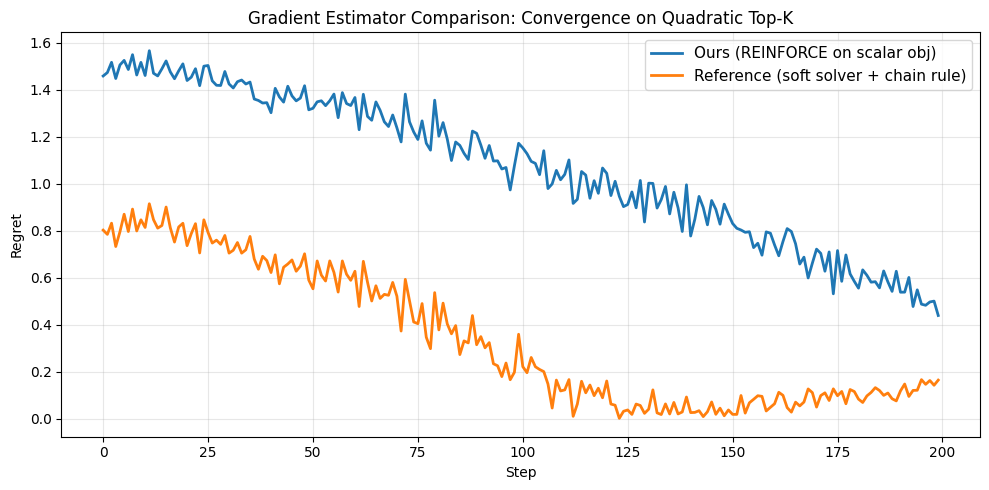

Final regret — ours: 0.438934, ref: 0.164028


In [12]:
# Toy optimization: learn theta to minimize regret
D, K, B = 8, 3, 1
N = 100
sigma = 0.1
lr = 0.0005
n_steps = 200

torch.manual_seed(123)
c_true = torch.randn(B, D)
alpha_q = 0.5

def topk_solver_toy(costs):
    _, idx = costs.topk(K, dim=-1)
    z = torch.zeros_like(costs)
    z.scatter_(-1, idx, 1.0)
    return z

def quad_obj_toy(z):
    return (c_true * z).sum(dim=-1) - alpha_q * (z ** 2).sum(dim=-1)

# Optimal solution (for regret computation)
z_star = topk_solver_toy(c_true)
obj_star = quad_obj_toy(z_star)

def run_optimization(method, seed=42):
    """Run gradient descent using either 'ours' or 'ref' gradient."""
    torch.manual_seed(seed)
    theta = torch.randn(B, D) * 0.1
    
    history = []
    for step in range(n_steps):
        torch.manual_seed(step)  # same noise per step for fair comparison
        
        if method == 'ours':
            e_obj, grad, _, _ = ours_forward_backward(
                theta, topk_solver_toy, quad_obj_toy, N, sigma
            )
        else:
            e_obj, grad = ref_forward_backward(
                theta, topk_solver_toy, quad_obj_toy, N, sigma
            )
        
        regret = (obj_star - e_obj).abs().item()
        history.append(regret)
        
        # Gradient ascent (maximize objective = minimize regret)
        theta = theta + lr * grad  # ascend to maximize obj
    
    return history

hist_ours = run_optimization('ours')
hist_ref = run_optimization('ref')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_ours, label='Ours (REINFORCE on scalar obj)', linewidth=2)
ax.plot(hist_ref, label='Reference (soft solver + chain rule)', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('Regret')
ax.set_title('Gradient Estimator Comparison: Convergence on Quadratic Top-K')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final regret — ours: {hist_ours[-1]:.6f}, ref: {hist_ref[-1]:.6f}")

## Test 4: Gradient Variance Comparison

Estimate the variance of each gradient estimator by running many independent
batches of N samples and measuring spread.

=== Gradient Statistics ===
                        Mean          Std     Mean |g|
Ours                0.003982     0.894451     0.713241
Reference           0.003827     0.939362     0.753929


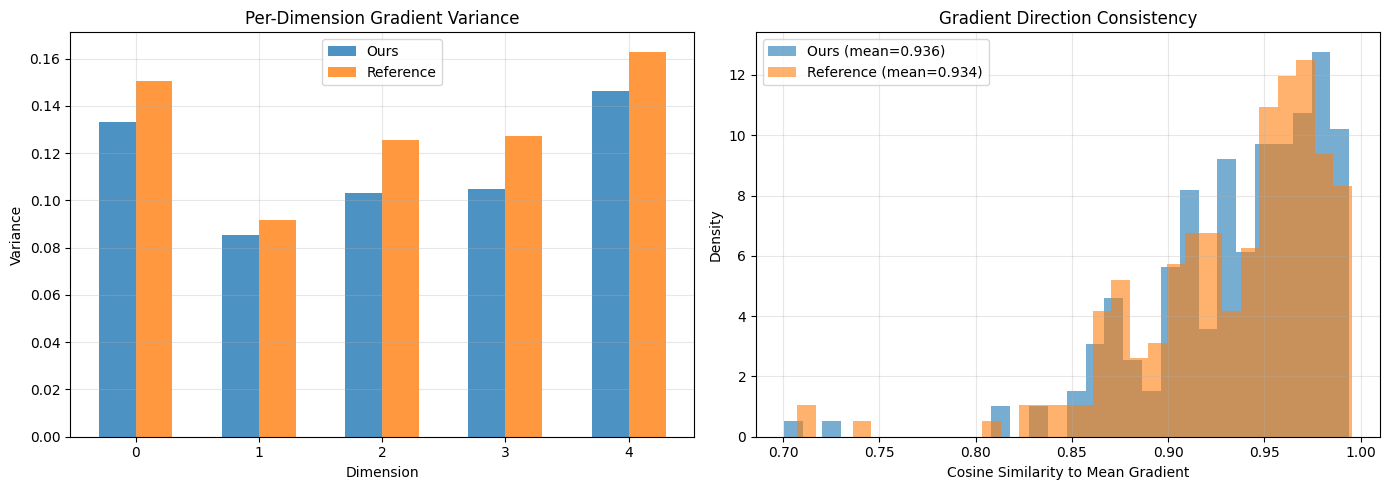

In [6]:
# Variance comparison
D, K, B = 5, 2, 1
N = 50
sigma = 0.5
n_trials = 200

torch.manual_seed(42)
theta = torch.randn(B, D)
c_true = torch.randn(B, D)

def topk_var(costs):
    _, idx = costs.topk(K, dim=-1)
    z = torch.zeros_like(costs)
    z.scatter_(-1, idx, 1.0)
    return z

def quad_var(z):
    return (c_true * z).sum(dim=-1) - 0.5 * (z ** 2).sum(dim=-1)

grads_ours = []
grads_ref = []

for t in range(n_trials):
    torch.manual_seed(t * 1000)
    _, g_o, _, _ = ours_forward_backward(theta, topk_var, quad_var, N, sigma)
    grads_ours.append(g_o.flatten())
    
    torch.manual_seed(t * 1000)
    _, g_r = ref_forward_backward(theta, topk_var, quad_var, N, sigma)
    grads_ref.append(g_r.flatten())

grads_ours = torch.stack(grads_ours)  # (n_trials, D)
grads_ref = torch.stack(grads_ref)    # (n_trials, D)

print("=== Gradient Statistics ===")
print(f"{'':15s} {'Mean':>12s} {'Std':>12s} {'Mean |g|':>12s}")
for name, g in [("Ours", grads_ours), ("Reference", grads_ref)]:
    print(f"{name:15s} {g.mean().item():12.6f} {g.std().item():12.6f} {g.abs().mean().item():12.6f}")

# Per-dimension variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
var_ours = grads_ours.var(dim=0).numpy()
var_ref = grads_ref.var(dim=0).numpy()
x = np.arange(D)
ax.bar(x - 0.15, var_ours, 0.3, label='Ours', alpha=0.8)
ax.bar(x + 0.15, var_ref, 0.3, label='Reference', alpha=0.8)
ax.set_xlabel('Dimension')
ax.set_ylabel('Variance')
ax.set_title('Per-Dimension Gradient Variance')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# Cosine similarity distribution between individual estimates and their respective means
mean_ours = grads_ours.mean(dim=0, keepdim=True)
mean_ref = grads_ref.mean(dim=0, keepdim=True)
cos_ours = torch.nn.functional.cosine_similarity(grads_ours, mean_ours).numpy()
cos_ref = torch.nn.functional.cosine_similarity(grads_ref, mean_ref).numpy()
ax.hist(cos_ours, bins=30, alpha=0.6, label=f'Ours (mean={cos_ours.mean():.3f})', density=True)
ax.hist(cos_ref, bins=30, alpha=0.6, label=f'Reference (mean={cos_ref.mean():.3f})', density=True)
ax.set_xlabel('Cosine Similarity to Mean Gradient')
ax.set_ylabel('Density')
ax.set_title('Gradient Direction Consistency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test 5: Sigma Sensitivity

How does each gradient estimator behave as σ varies? Plot gradient magnitude and
cosine similarity to a high-sample "ground truth" for a range of sigmas.

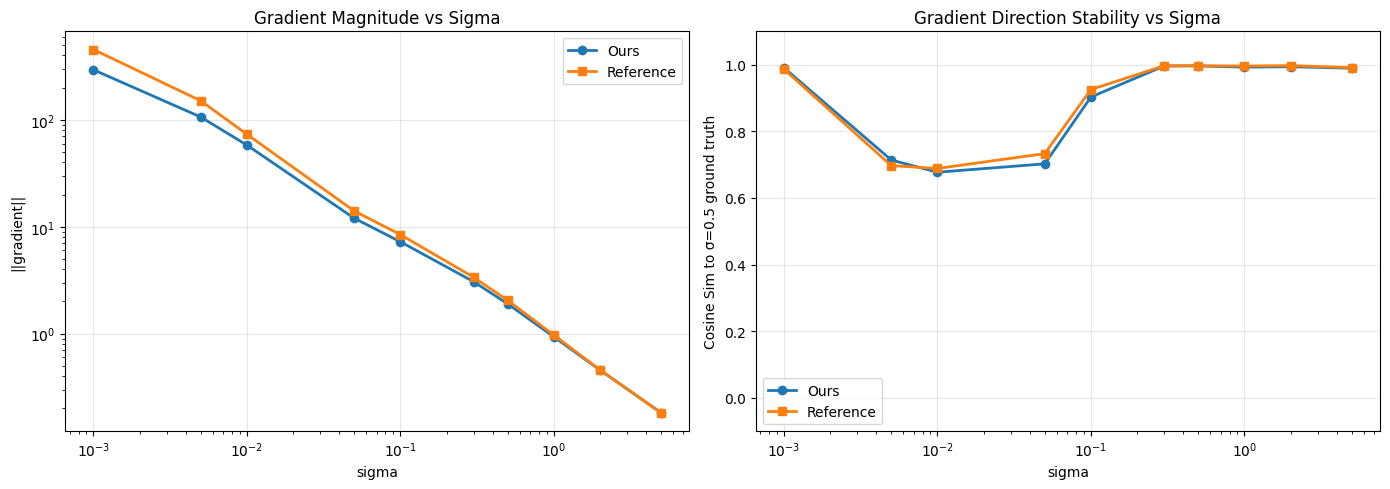

In [7]:
# Sigma sensitivity
D, K, B = 5, 2, 1
N = 500

torch.manual_seed(42)
theta = torch.randn(B, D)
c_true = torch.randn(B, D)

sigmas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]

def topk_sig(costs):
    _, idx = costs.topk(K, dim=-1)
    z = torch.zeros_like(costs)
    z.scatter_(-1, idx, 1.0)
    return z

def quad_sig(z):
    return (c_true * z).sum(dim=-1) - 0.5 * (z ** 2).sum(dim=-1)

# High-sample reference gradient (our method, N=50000)
torch.manual_seed(999)
_, grad_truth_ours, _, _ = ours_forward_backward(theta, topk_sig, quad_sig, 50000, 0.5)
torch.manual_seed(999)
_, grad_truth_ref = ref_forward_backward(theta, topk_sig, quad_sig, 50000, 0.5)

mag_ours, mag_ref = [], []
cos_ours, cos_ref = [], []

for s in sigmas:
    torch.manual_seed(0)
    _, g_o, _, _ = ours_forward_backward(theta, topk_sig, quad_sig, N, s)
    torch.manual_seed(0)
    _, g_r = ref_forward_backward(theta, topk_sig, quad_sig, N, s)
    
    mag_ours.append(g_o.norm().item())
    mag_ref.append(g_r.norm().item())
    
    cos_o = torch.nn.functional.cosine_similarity(
        g_o.flatten().unsqueeze(0), grad_truth_ours.flatten().unsqueeze(0)
    ).item()
    cos_r = torch.nn.functional.cosine_similarity(
        g_r.flatten().unsqueeze(0), grad_truth_ref.flatten().unsqueeze(0)
    ).item()
    cos_ours.append(cos_o)
    cos_ref.append(cos_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sigmas, mag_ours, 'o-', label='Ours', linewidth=2)
ax.plot(sigmas, mag_ref, 's-', label='Reference', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('sigma')
ax.set_ylabel('||gradient||')
ax.set_title('Gradient Magnitude vs Sigma')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sigmas, cos_ours, 'o-', label='Ours', linewidth=2)
ax.plot(sigmas, cos_ref, 's-', label='Reference', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('sigma')
ax.set_ylabel('Cosine Sim to σ=0.5 ground truth')
ax.set_title('Gradient Direction Stability vs Sigma')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

## Summary

| Property | Reference (`perturbations.py`) | Ours (`perturbedOptFunc`) |
|----------|-------------------------------|---------------------------|
| What it differentiates | Solution map: $\mathbb{E}[z(\theta+\sigma\varepsilon)]$ | Scalar objective: $\mathbb{E}[f(z(\theta+\sigma\varepsilon))]$ |
| Backward pass | Jacobian × upstream `dy` | REINFORCE with obj as score |
| Equivalent for linear obj? | ✓ Yes | ✓ Yes |
| Equivalent for nonlinear obj? | ✗ No | ✗ No |
| Which is "correct"? | Differentiates $f(\bar{z}(\theta))$ where $\bar{z}$ = soft solver | Differentiates $\bar{f}(\theta) = \mathbb{E}[f(z)]$ directly |
| Variance | Lower (solution smoothing) | Higher (scalar score × noise) |
| Bias | Biased by Jensen gap: $f(\mathbb{E}[z]) \neq \mathbb{E}[f(z)]$ | Unbiased for $\nabla \mathbb{E}[f(z)]$ |

### Implications for the benchmark

- Portfolio (quadratic QP): the reference approach may give **lower-variance, better-directed** gradients because it smooths the solution map rather than the scalar objective.
- Knapsack/bipartite (combinatorial): both are noisy approximations; the reference approach preserves more structure via the solution vector.
- **Potential improvement**: switch to reference-style gradient (differentiate the soft solver, chain-rule through the objective) for all problems. This is a one-function change in `perturbedOptFunc.backward()`.